---
title: "Eigendecomposition"
categories: []
---


The spectral theorem of Chapter 2 settles the story for *symmetric* matrices: every symmetric matrix admits an orthonormal basis of real eigenvectors. A general square matrix enjoys no such guarantee, and two genuinely new phenomena appear. First, eigenvalues may be [complex]{.mark}, even for a matrix with real entries. Second, the eigenvectors may fail to *span* the whole space, so the matrix cannot be diagonalized at all. This chapter develops the theory that handles both.

Three facts anchor everything that follows. The eigenvalues are exactly the roots of a single degree-$n$ polynomial, the [characteristic polynomial]{.mark}; they can be located without solving anything through [Gershgorin's circle theorem]{.mark}; and, when a matrix *is* diagonalizable, its powers, trace, and determinant all reduce to scalars. The chapter closes with the [power method]{.mark}, the simplest algorithm for finding the dominant eigenvalue, which is the computational engine behind [PageRank](https://en.wikipedia.org/wiki/PageRank).


## Eigenvalues and eigenvectors

A nonzero vector $\mathbf{v}$ is an **eigenvector** of $\mathbf{A}\in\mathbb{R}^{n\times n}$ when the action of $\mathbf{A}$ on it is pure scaling:

$$\mathbf{A}\mathbf{v} = \lambda\mathbf{v}.$$

The scalar $\lambda$ is the corresponding **eigenvalue**. The defining equation says that on the line spanned by $\mathbf{v}$, the linear map $\mathbf{A}$ acts as multiplication by $\lambda$ — the direction is preserved, only the length changes.

Two immediate observations. First, $\lambda$ is an eigenvalue exactly when $\lambda\mathbf{I} - \mathbf{A}$ fails to be invertible, because that failure is equivalent to the existence of a nonzero $\mathbf{v}$ with $(\lambda\mathbf{I}-\mathbf{A})\mathbf{v}=\mathbf{0}$. Second, $\lambda = 0$ is an eigenvalue precisely when $\mathbf{A}$ has a nontrivial null space, i.e. $\mathbf{A}$ is singular.

Eigenvectors for a given eigenvalue are not unique: any nonzero scalar multiple is again an eigenvector, and the set of all of them (together with $\mathbf{0}$) forms a subspace.


## Existence and the characteristic polynomial

Whether $\lambda\mathbf{I}-\mathbf{A}$ is invertible is decided by its determinant. Define the **characteristic polynomial**

$$p_{\mathbf{A}}(\lambda) = \det(\lambda\mathbf{I} - \mathbf{A}).$$

Expanding the determinant shows $p_{\mathbf{A}}$ is a monic polynomial of degree $n$ in $\lambda$. Since a matrix is singular exactly when its determinant vanishes, $\lambda$ is an eigenvalue of $\mathbf{A}$ if and only if $p_{\mathbf{A}}(\lambda)=0$.

The [fundamental theorem of algebra](https://en.wikipedia.org/wiki/Fundamental_theorem_of_algebra) factors $p_{\mathbf{A}}$ over $\mathbb{C}$:

$$p_{\mathbf{A}}(\lambda) = \prod_{i=1}^{s} (\lambda - \lambda_i)^{r_i}, \qquad r_1 + \cdots + r_s = n,$$

where $\lambda_1,\dots,\lambda_s$ are the distinct eigenvalues. The exponent $r_i$ is the **algebraic multiplicity** of $\lambda_i$. A real matrix therefore has exactly $n$ eigenvalues counted with multiplicity, though they may be complex; and it has *at most* $n$ distinct ones.


## Gershgorin's circle theorem

The eigenvalues are the roots of a degree-$n$ polynomial, which in general cannot be found in closed form. But they can be *localized* cheaply. For each row $i$, define the **Gershgorin disk**

$$D_i = \Big\{\, z\in\mathbb{C} : |z - a_{ii}| \le r_i \,\Big\}, \qquad r_i = \sum_{j \ne i} |a_{ij}|,$$

centered at the diagonal entry $a_{ii}$ with radius equal to the sum of the off-diagonal moduli in row $i$.

**Gershgorin's circle theorem.** *Every eigenvalue of $\mathbf{A}$ lies in the union $D_{\mathbf{A}} = \bigcup_{i=1}^n D_i$ of the Gershgorin disks.*

To see why, take an eigenpair $\mathbf{A}\mathbf{v}=\lambda\mathbf{v}$ and choose an index $i$ with $|v_i| = \max_j |v_j| = \lVert\mathbf{v}\rVert_\infty$. The $i$-th component of the equation reads

$$(\lambda - a_{ii}) v_i = \sum_{j\ne i} a_{ij} v_j,$$

so, dividing by $v_i$ and taking moduli,

$$|\lambda - a_{ii}| \le \sum_{j\ne i} |a_{ij}|\, \frac{|v_j|}{|v_i|} \le \sum_{j\ne i} |a_{ij}| = r_i.$$

Thus $\lambda \in D_i$. The theorem is a one-line bound with real teeth: it certifies, for instance, that a [strictly diagonally dominant](https://en.wikipedia.org/wiki/Diagonally_dominant_matrix) matrix (one with $|a_{ii}| > r_i$ for every $i$) has no zero eigenvalue, hence is invertible.

::: {.callout-note}
The disks are drawn from row sums, but the column sums give an identical bound, since $\mathbf{A}$ and $\mathbf{A}^{\mathsf T}$ share eigenvalues.
:::


In [1]:
from watchtower.core import set_format
set_format("svg")


eigenvalues: [ 3.162+0.j  3.   +0.j -3.162+0.j]


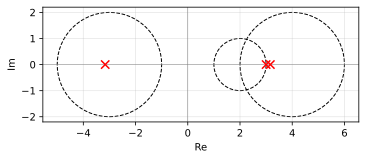

In [2]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[2.0, -1.0,  0.0],
              [1.0,  4.0, -1.0],
              [-1.0, -1.0, -3.0]])

fig, ax = plt.subplots(figsize=(5.2, 5.2))
for i in range(A.shape[0]):
    center = A[i, i]
    radius = np.sum(np.abs(A[i, :])) - abs(A[i, i])
    ax.add_patch(plt.Circle((center, 0), radius,
                            fill=False, ec='k', ls='--', lw=1))

eigs = np.linalg.eigvals(A)
ax.scatter(eigs.real, eigs.imag, marker='x', s=70, color='r', zorder=3)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.set_xlabel('Re'); ax.set_ylabel('Im')
ax.grid(True, alpha=0.3); fig.tight_layout()

print('eigenvalues:', np.round(eigs, 3))


**Gershgorin localization.**

Each eigenvalue (red cross) lies inside the union of the three disks, as the theorem guarantees. Here the disks overlap, but the localization is already informative: the spectrum is confined to $[-5, 6]$, and the disk at $a_{33}=-3$ of radius $2$ isolates a single eigenvalue in the left half-plane.

The theorem generalizes: a similarity transform $\mathbf{A}\mapsto \mathbf{D}\mathbf{A}\mathbf{D}^{-1}$ with positive diagonal $\mathbf{D}$ preserves the spectrum while rescaling the off-diagonal entries, and a clever choice of $\mathbf{D}$ can shrink the localization arbitrarily.


## Diagonalization

A matrix is **diagonalizable** when it possesses $n$ linearly independent eigenvectors. Collect them as the columns of $\mathbf{V}$ and the eigenvalues as $\boldsymbol{\Lambda}=\operatorname{diag}(\lambda_1,\dots,\lambda_n)$; the eigen-equations $\mathbf{A}\mathbf{v}_i = \lambda_i\mathbf{v}_i$ assemble into $\mathbf{A}\mathbf{V} = \mathbf{V}\boldsymbol{\Lambda}$, and since $\mathbf{V}$ is invertible,

$$\boxed{\;\mathbf{A} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^{-1}.\;}$$

In the eigenbasis the map is *diagonal*: it stretches coordinate $i$ by $\lambda_i$ and mixes nothing. Powers collapse to scalars,

$$\mathbf{A}^k = \mathbf{V}\boldsymbol{\Lambda}^k\mathbf{V}^{-1},$$

which is the reason diagonalization matters for any iterated dynamics.

One subtlety worth recording. Expanding $\mathbf{A}=\mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^{-1}$ as a sum of rank-one terms gives

$$\mathbf{A} = \sum_{i=1}^{n} \lambda_i\, \mathbf{v}_i \mathbf{w}_i^{\mathsf T},$$

where $\mathbf{w}_i^{\mathsf T}$ is the $i$-th *row* of $\mathbf{V}^{-1}$, i.e. the [left eigenvector]{.mark} $\mathbf{A}^{\mathsf T}\mathbf{w}_i = \lambda_i \mathbf{w}_i$. The two families are [biorthogonal]{.mark}, $\mathbf{w}_i^{\mathsf T}\mathbf{v}_j = \delta_{ij}$. Only when $\mathbf{A}$ is symmetric (Chapter 2) do the two coincide, $\mathbf{w}_i = \mathbf{v}_i$, collapsing this to the spectral theorem's $\mathbf{A}=\sum_i\lambda_i\mathbf{v}_i\mathbf{v}_i^{\mathsf T}$.


In [3]:
import numpy as np

rng = np.random.default_rng(1)
A = rng.standard_normal((4, 4))

lam, V = np.linalg.eig(A)
# reconstruct A = V Lambda V^{-1}
recon = (V @ np.diag(lam)) @ np.linalg.inv(V)
print('max |A - V Lambda V^{-1}| =', np.max(np.abs(A - recon)))

# powers collapse: A^5 = V Lambda^5 V^{-1}
k = 5
err_pow = np.max(np.abs(np.linalg.matrix_power(A, k) - (V @ np.diag(lam**k)) @ np.linalg.inv(V)))
print(f'max |A^5 - V Lambda^5 V^{-1}| = {err_pow:.2e}')

# left eigenvectors: rows of V^{-1} are biorthogonal to the columns of V
W = np.linalg.inv(V)
print('max |W V - I|              =', np.max(np.abs(W @ V - np.eye(4))))
print('max |A^T W^T - W^T Lambda| =', np.max(np.abs(A.T @ W.T - W.T @ np.diag(lam))))


max |A - V Lambda V^{-1}| = 1.44349424796038e-15
max |A^5 - V Lambda^5 V^-1| = 1.60e-14
max |W V - I|              = 2.222087621814296e-16
max |A^T W^T - W^T Lambda| = 1.3325180118266506e-15


The reconstruction and the power identity both hold to machine precision, and the two final checks confirm that the rows of $\mathbf{W}=\mathbf{V}^{-1}$ are left eigenvectors. The diagonalization is exact for this generic matrix, and that is the point: *generic* matrices are diagonalizable, and the failure is a measure-zero, structurally special event.


## When diagonalization fails

Not every matrix is diagonalizable. Consider

$$\mathbf{A} = \begin{bmatrix} 1 & 0 \\ 1 & 1 \end{bmatrix}.$$

Its characteristic polynomial is $(1-\lambda)^2$, so $\lambda=1$ has algebraic multiplicity $2$. But the eigen-equation $(\mathbf{A}-\mathbf{I})\mathbf{v}=\mathbf{0}$ is

$$\begin{bmatrix} 0 & 0 \\ 1 & 0 \end{bmatrix}\begin{bmatrix} v_1 \\ v_2 \end{bmatrix} = \mathbf{0} \quad\Longrightarrow\quad v_1 = 0,$$

so every eigenvector is a multiple of $[0,\ 1]^{\mathsf T}$. The eigenspace is one-dimensional, and $\mathbf{A}$ has no second independent eigenvector — it cannot be diagonalized. Such a matrix is called [defective](https://en.wikipedia.org/wiki/Defective_matrix), and its structure is a [Jordan block](https://en.wikipedia.org/wiki/Jordan_normal_form) rather than a diagonal of scalars.


In [4]:
import numpy as np

A = np.array([[1.0, 0.0],
              [1.0, 1.0]])

lam, V = np.linalg.eig(A)
print('eigenvalues :', lam)
print('rank of V   :', np.linalg.matrix_rank(V), '(needs 2 to diagonalize)')

# try to reconstruct: V is singular so A = V Lambda V^{-1} is impossible
print('det(V)      :', np.linalg.det(V))


eigenvalues : [1.+0.j 1.+0.j]
rank of V   : 1 (needs 2 to diagonalize)
det(V)      : (-2.2204460492503185e-16+0j)


NumPy reports the two (equal) eigenvalues, but the eigenvector matrix $\mathbf{V}$ has rank $1$ — a numerical smoking gun for defectiveness. The matrix still has a perfectly good theory (the Jordan form), but it is not of the tidy diagonal kind, and its powers grow *polynomially* rather than geometrically: $\mathbf{A}^k = \begin{bmatrix}1&0\\ k&1\end{bmatrix}$.


## Geometric multiplicity is bounded by algebraic multiplicity

The **eigenspace** of $\lambda$ is $E_\lambda = \operatorname{N}(\lambda\mathbf{I}-\mathbf{A})$, and its dimension is the **geometric multiplicity** of $\lambda$. The geometric multiplicity counts independent eigenvectors; the algebraic multiplicity counts how many times $\lambda$ is a root of $p_{\mathbf{A}}$. The two need not agree — the defective matrix above has algebraic multiplicity $2$ but geometric multiplicity $1$ — but they are ordered.

**Proposition.** *For every eigenvalue, geometric multiplicity $\le$ algebraic multiplicity.*

Let $k = \dim E_\lambda$ and extend a basis $\mathbf{v}_1,\dots,\mathbf{v}_k$ of $E_\lambda$ to a basis of $\mathbb{R}^n$, collected as columns of an invertible $\mathbf{V}$. Since each $\mathbf{v}_i$ is a $\lambda$-eigenvector,

$$\mathbf{A}\mathbf{V} = \mathbf{V}\begin{bmatrix} \lambda \mathbf{I}_k & \mathbf{C} \\ \mathbf{0} & \mathbf{D} \end{bmatrix},$$

so $\mathbf{A}$ is similar to that block-upper-triangular matrix. The characteristic polynomial is invariant under similarity, and the determinant of a block-triangular matrix is the product of the block determinants:

$$p_{\mathbf{A}}(\mu) = \det(\mu\mathbf{I}-\mathbf{A}) = \det\big((\mu-\lambda)\mathbf{I}_k\big)\,\det(\mu\mathbf{I}_{n-k}-\mathbf{D}) = (\mu-\lambda)^k \det(\mu\mathbf{I}_{n-k}-\mathbf{D}).$$

Hence $(\mu-\lambda)^k$ divides $p_{\mathbf{A}}(\mu)$, so the algebraic multiplicity of $\lambda$ is at least $k$. In particular, $\mathbf{A}$ is diagonalizable exactly when every eigenvalue has geometric multiplicity equal to its algebraic multiplicity.


## Eigenspaces are invariant subspaces

An eigenspace is the simplest kind of [invariant subspace](https://en.wikipedia.org/wiki/Invariant_subspace): $\mathbf{A}$ maps $E_\lambda$ into itself, since $\mathbf{A}\mathbf{v}=\lambda\mathbf{v}\in E_\lambda$. This constrains the geometry of a matrix. Consider

$$\mathbf{B} = \begin{bmatrix} 0 & 1 & 0 \\ -1 & 0 & 0 \\ 0 & 0 & -5 \end{bmatrix},$$

a rotation by $\pi/2$ in the $xy$-plane combined with scaling by $-5$ along the $z$-axis. The $xy$-plane is a two-dimensional invariant subspace, but the restriction of $\mathbf{B}$ to it is a *rotation*, which has no real eigenvectors (no real vector is mapped to a scalar multiple of itself by a $90^\circ$ rotation). Hence $\mathbf{B}$ has no real eigendecomposition; its eigenvalues are $\pm i$ and $-5$. This is the generic picture for real matrices with complex eigenvalues: they rotate inside a real invariant plane.


## Triangular matrices

For an upper- or lower-triangular matrix, the eigenvalues are the diagonal entries. The reason is that $\mu\mathbf{I}-\mathbf{A}$ remains triangular with diagonal $\mu-a_{11},\dots,\mu-a_{nn}$, and the determinant of a triangular matrix is the product of its diagonal entries:

$$p_{\mathbf{A}}(\mu) = \prod_{i=1}^n (\mu - a_{ii}).$$

Schur's theorem says every square matrix is unitarily similar to an upper-triangular one (its [Schur form](https://en.wikipedia.org/wiki/Schur_decomposition)), and the [QR algorithm](https://en.wikipedia.org/wiki/QR_algorithm) realizes exactly this reduction by orthogonal similarity transformations, which is why an $O(n^3)$ algorithm suffices to compute the full spectrum.

## Trace and determinant

Two scalar invariants of $\mathbf{A}$ are determined by its eigenvalues, whether or not $\mathbf{A}$ is diagonalizable:

$$\boxed{\;\det\mathbf{A} = \prod_{i=1}^n \lambda_i, \qquad \operatorname{tr}\mathbf{A} = \sum_{i=1}^n \lambda_i.\;}$$

Both follow from matching coefficients of $p_{\mathbf{A}}(\mu)=\prod_i(\mu-\lambda_i)$. For the determinant, evaluate at $\mu=0$:

$$p_{\mathbf{A}}(0) = \det(-\mathbf{A}) = (-1)^n\det\mathbf{A} = \prod_i (-\lambda_i) = (-1)^n\prod_i \lambda_i,$$

so $\det\mathbf{A}=\prod_i\lambda_i$. For the trace, the coefficient of $\mu^{n-1}$ in $\det(\mu\mathbf{I}-\mathbf{A})$ is $-\sum_i a_{ii} = -\operatorname{tr}\mathbf{A}$, because a term contributing $\mu^{n-1}$ picks $n-1$ diagonal factors $\mu$ and one diagonal entry $-a_{ii}$. Matching against $-\sum_i\lambda_i$ from the factored form gives $\operatorname{tr}\mathbf{A}=\sum_i\lambda_i$.


In [5]:
import numpy as np

rng = np.random.default_rng(3)
A = rng.standard_normal((5, 5))
lam = np.linalg.eigvals(A)

print('det(A)        =', np.linalg.det(A))
print('prod(eigvals) =', np.prod(lam))
print('tr(A)         =', np.trace(A))
print('sum(eigvals)  =', np.sum(lam))


det(A)        = 1.8269058625543482
prod(eigvals) = (1.8269058625543453-4.273745946688848e-17j)
tr(A)         = 0.5145653024486103
sum(eigvals)  = (0.5145653024486097+0j)


Both identities hold even though $\mathbf{A}$ is a generic non-symmetric matrix with complex eigenvalues. The trace identity explains a useful shortcut: for any square matrix, $\operatorname{tr}(\mathbf{A}^{\mathsf T}\mathbf{A}) = \sum_i \sigma_i^2 = \lVert\mathbf{A}\rVert_{\mathrm{F}}^2$, connecting the Frobenius norm of Chapter 1 to the singular values of Chapter 3.


## Complex eigenvalues come in conjugate pairs

For a *real* matrix, the complex eigenvalues occur in conjugate pairs. Taking the complex conjugate of $\mathbf{A}\mathbf{v}=\lambda\mathbf{v}$ gives $\mathbf{A}\bar{\mathbf{v}}=\bar{\lambda}\bar{\mathbf{v}}$ (since $\mathbf{A}$ is real, $\bar{\mathbf{A}}=\mathbf{A}$), so $\bar{\lambda}$ is an eigenvalue with eigenvector $\bar{\mathbf{v}}$. This is why $\det\mathbf{A}=\prod_i\lambda_i$ is real even when individual $\lambda_i$ are complex, and why a real matrix of odd order always has at least one real eigenvalue: the complex eigenvalues pair up, leaving an odd count to be real.


## The power method

Suppose $\mathbf{A}$ is diagonalizable with a *dominant* eigenvalue, $|\lambda_1| > |\lambda_2| \ge \cdots \ge |\lambda_n|$. Write an arbitrary starting vector $\mathbf{x}_0$ in the eigenbasis, $\mathbf{x}_0 = \sum_i c_i\mathbf{v}_i$ with $c_1\ne 0$. Iterating $\mathbf{x}_{k+1}=\mathbf{A}\mathbf{x}_k$,

$$\mathbf{x}_k = \mathbf{A}^k\mathbf{x}_0 = \lambda_1^k\left( c_1\mathbf{v}_1 + \sum_{i\ge 2} c_i\left(\frac{\lambda_i}{\lambda_1}\right)^{k}\mathbf{v}_i\right),$$

and every term with $i\ge 2$ decays like $|\lambda_i/\lambda_1|^k$. The iterates align with $\mathbf{v}_1$ at rate $|\lambda_2/\lambda_1|$, and the [Rayleigh quotient](https://en.wikipedia.org/wiki/Rayleigh_quotient) of Chapter 2 converges to $\lambda_1$:

$$\frac{\mathbf{x}_k^{\mathsf T}\mathbf{A}\mathbf{x}_k}{\mathbf{x}_k^{\mathsf T}\mathbf{x}_k} \longrightarrow \lambda_1.$$

Normalizing at each step keeps $\mathbf{x}_k$ from overflowing or underflowing, giving the **power method**:

$$\mathbf{x}_{k+1} = \frac{\mathbf{A}\mathbf{x}_k}{\lVert\mathbf{A}\mathbf{x}_k\rVert_2}, \qquad \mu_k = \mathbf{x}_k^{\mathsf T}\mathbf{A}\mathbf{x}_k.$$

This is the algorithm behind [PageRank](https://en.wikipedia.org/wiki/PageRank): the web's link structure forms a sparse matrix, and its dominant eigenvector (found by the power method) ranks pages. The method's virtue is that it needs only matrix-vector products, never a factorization.


lambda_1 = -2.003712,  |lambda_2/lambda_1| = 0.906
mu_200   = -2.003712


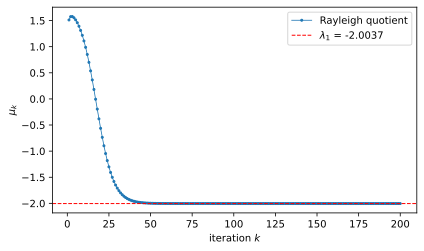

In [6]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
B = rng.standard_normal((6, 6))
A = (B + B.T) / 2                     # <1>

lam = np.linalg.eigvalsh(A)           # <2>
lam1 = lam[np.argmax(np.abs(lam))]
lam2 = lam[np.argsort(-np.abs(lam))[1]]

x = rng.standard_normal(6)
x /= np.linalg.norm(x)
mu = []
for k in range(1, 201):
    x = A @ x
    x /= np.linalg.norm(x)            # <3>
    mu.append(x @ A @ x)              # <4>

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(range(1, 201), mu, marker='o', ms=2, lw=0.8, label='Rayleigh quotient')
ax.axhline(lam1, color='r', ls='--', lw=1, label=rf'$\lambda_1$ = {lam1:.4f}')
ax.set_xlabel('iteration $k$'); ax.set_ylabel(r'$\mu_k$')
ax.legend(); fig.tight_layout()

print(f'lambda_1 = {lam1:.6f},  |lambda_2/lambda_1| = {abs(lam2/lam1):.3f}')
print(f'mu_200   = {mu[-1]:.6f}')


**Power method convergence.**

- `<1>` A symmetric matrix keeps the eigenvalues real and the eigenvectors orthogonal, the cleanest setting for the method.
- `<2>` Ground-truth eigenvalues for comparison, computed by a dense solver.
- `<3>` Renormalization is what distinguishes the *power method* from raw iteration of $\mathbf{A}^k$; it prevents overflow and keeps the vector a unit vector.
- `<4>` The Rayleigh quotient $\mu_k = \mathbf{x}_k^{\mathsf T}\mathbf{A}\mathbf{x}_k$ converges to $\lambda_1$ faster than the vector $\mathbf{x}_k$ itself.

The quotient converges to $\lambda_1$, but slowly, because the printed ratio $|\lambda_2/\lambda_1|=0.906$ is close to $1$: the eigenvector error decays by only a factor $0.906$ per step. The Rayleigh quotient compensates with [quadratic convergence](https://en.wikipedia.org/wiki/Rate_of_convergence), its error shrinking like $|\lambda_2/\lambda_1|^{2k}$, so a couple hundred iterations still pin $\lambda_1$ to six decimals. A well-separated dominant eigenvalue converges in a handful of steps; here the gap is deliberately narrow to make the rate visible. The one failure mode is a tie, $|\lambda_1|=|\lambda_2|$, for instance a dominant complex conjugate pair: the iterates then oscillate between the two directions instead of settling, and the plain power method must be replaced by a subspace (block) variant.


## How much do eigenvalues move? Weyl's bound

Data matrices are perturbed matrices: measurements carry noise, rounding leaves residue, and what a solver actually diagonalizes is $\mathbf{A}+\mathbf{E}$ rather than $\mathbf{A}$. For symmetric matrices the answer is clean. [Weyl's inequality]{.mark}: if $\rho(\mathbf{E}) = \lVert\mathbf{E}\rVert_2$, then for every $k$

$$\boxed{\lvert\lambda_k(\mathbf{A}+\mathbf{E}) - \lambda_k(\mathbf{A})\rvert \le \rho(\mathbf{E}).}$$

Each eigenvalue moves by at most the size of the perturbation, in absolute terms, no matter how the eigenvectors are arranged. The proof is two applications of the Courant-Fischer characterization from chapter 2, $\lambda_k(\mathbf{M}) = \max_{\dim\mathcal{S}=k}\ \min_{\substack{\mathbf{x}\in\mathcal{S}\\ \lVert\mathbf{x}\rVert=1}}\mathbf{x}^{\mathsf T}\mathbf{M}\mathbf{x}$. Since $|\mathbf{x}^{\mathsf T}\mathbf{E}\mathbf{x}| \le \rho(\mathbf{E})$ for every unit $\mathbf{x}$,

$$\lambda_k(\mathbf{A}+\mathbf{E}) = \max_{\dim\mathcal{S}=k}\min_{\mathbf{x}}\big(\mathbf{x}^{\mathsf T}\mathbf{A}\mathbf{x} + \mathbf{x}^{\mathsf T}\mathbf{E}\mathbf{x}\big) \;\ge\; \max_{\dim\mathcal{S}=k}\Big(\min_{\mathbf{x}}\mathbf{x}^{\mathsf T}\mathbf{A}\mathbf{x} - \rho(\mathbf{E})\Big) = \lambda_k(\mathbf{A}) - \rho(\mathbf{E}),$$

and swapping the roles of $\mathbf{A}$ and $\mathbf{A}+\mathbf{E}$ gives the matching upper bound. For normal matrices more is true in aggregate: the [Hoffman-Wielandt inequality](https://en.wikipedia.org/wiki/Hoffman%E2%80%93Wielandt_theorem) matches the eigenvalues pairwise as $\sum_i\lvert\mu_i-\lambda_i\rvert^2 \le \lVert\mathbf{E}\rVert_{\mathrm F}^2$.

Eigenvalues are perfectly conditioned; eigenvectors are not. Let $\lambda_1 > \lambda_2 \ge \dots$ be the eigenvalues of symmetric $\mathbf{A}$ with gap $\gamma = \lambda_1 - \lambda_2$, and let $(\mu, \mathbf{w})$ be an eigenpair of $\mathbf{A}+\mathbf{E}$ with $\mu$ near $\lambda_1$. The residual obeys $\mathbf{r} = (\mathbf{A}-\mu\mathbf{I})\mathbf{w} = -\mathbf{E}\mathbf{w}$, so $\lVert\mathbf{r}\rVert \le \rho(\mathbf{E})$. Expanding $\mathbf{w} = \sum_i c_i\mathbf{u}_i$ in the eigenbasis of $\mathbf{A}$,

$$\lVert\mathbf{r}\rVert^2 = \sum_i c_i^2(\lambda_i-\mu)^2 \;\ge\; (\gamma - \rho(\mathbf{E}))^2 \sum_{i\ge 2} c_i^2,$$

because every old eigenvalue except $\lambda_1$ lies at distance at least $\gamma - \rho(\mathbf{E})$ from $\mu$: Weyl pins $\mu$ within $\rho(\mathbf{E})$ of $\lambda_1$, while $\lambda_i \le \lambda_1 - \gamma$ for $i \ge 2$. The sum on the right is exactly the squared distance from $\mathbf{w}$ to the line spanned by $\mathbf{u}_1$, which for unit vectors is $\sin^2\theta$, the sine of the angle between them. Provided $\rho(\mathbf{E}) \le \gamma/2$,

$$\boxed{\sin\theta(\mathbf{w}, \mathbf{u}_1) \;\le\; \frac{2\,\rho(\mathbf{E})}{\lambda_1 - \lambda_2}.}$$

This is the simplest case of the [Davis-Kahan $\sin\theta$ theorem](https://en.wikipedia.org/wiki/Davis%E2%80%93Kahan_theorem); the general version bounds the angles between invariant subspaces by the perturbation norm divided by the spectral gap surrounding them. The message for practice: eigenvalue error is absolute, eigenvector error scales like the inverse gap. A perturbation of size $10^{-3}$ is invisible in the spectrum of a matrix whose top eigenvalues differ by $O(1)$, yet it can rotate a pair split by $10^{-3}$ through angles of order one.

**Numerical check.** Same perturbation norm, two spectra: one with a healthy top gap, one with the top two eigenvalues nearly tied.

In [7]:
import numpy as np

def top_eigenpair_experiment(lam_desc, e_norm):
    n = len(lam_desc)
    rng = np.random.default_rng(7)
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    A = Q @ np.diag(np.sort(lam_desc)) @ Q.T            # symmetric with the given spectrum
    u1, u2 = Q[:, -1], Q[:, -2]
    F = e_norm * (np.outer(u1, u2) + np.outer(u2, u1))  # ||F||_2 = e_norm, aimed at the top pair
    mu, W = np.linalg.eigh(A + F)
    w1 = W[:, -1]
    if u1 @ w1 < 0:
        w1 = -w1
    sin_theta = np.sqrt(max(0.0, 1.0 - (u1 @ w1) ** 2))
    return abs(mu[-1] - lam_desc[0]), sin_theta

e_norm = 5e-3
scenarios = {
    'well-separated (gap 1)':   np.concatenate([[10.0, 9.0], np.linspace(-8.0, 0.0, 38)]),
    'clustered top (gap 1e-3)': np.concatenate([[10.0, 10.0 - 1e-3], np.linspace(-8.0, 0.0, 38)]),
}
for name, lam in scenarios.items():
    dlam, st = top_eigenpair_experiment(lam, e_norm)
    print(f'{name}:  |dlam_1|={dlam:.2e} (bound {e_norm:.0e}),  '
          f'sin(theta)={st:.2e} (bound {min(1.0, 2 * e_norm / (lam[0] - lam[1])):.2f})')

well-separated (gap 1):  |dlam_1|=2.50e-05 (bound 5e-03),  sin(theta)=5.00e-03 (bound 0.01)
clustered top (gap 1e-3):  |dlam_1|=4.52e-03 (bound 5e-03),  sin(theta)=6.71e-01 (bound 1.00)


The experiment confirms the split personality: the top eigenvalue moves by at most $\rho(\mathbf{E})$ in both scenarios, while the top eigenvector stays put only when the gap is generous. When spectra cluster, individual eigenvectors are meaningful only through the subspace they span, which is why practical algorithms (and chapter 13) target subspaces rather than single directions whenever the gap is thin.

## Summary

The eigendecomposition generalizes the spectral theorem at the cost of two complications: complex eigenvalues and defective matrices. The eigenvalues are the roots of the characteristic polynomial, localized by Gershgorin disks and read off directly for triangular matrices; the trace and determinant are their sum and product. When $n$ independent eigenvectors exist the matrix diagonalizes, $\mathbf{A}=\mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^{-1}$, and iterated dynamics reduce to scalar powers. When they do not, the matrix is defective and the Jordan form takes over. The power method turns the dominant-eigenvalue theory into an algorithm needing only matrix-vector products — the bridge from this chapter's theory to the least-squares optimization of Chapter 8 and the quadratic forms of Chapter 10.


## Problems

The problems below exercise the chapter's main results: Gershgorin localization, diagonalizability, defective matrices, and the power method. Problems 1 and 2 are theory; Problems 3 and 4 are computational; Problem 5 is a numerical experiment.


### [P9.1] Strict diagonal dominance implies invertibility

Let $\mathbf{A}\in\mathbb{R}^{n\times n}$ be [strictly diagonally dominant]{.mark}: $|a_{ii}| > r_i$ for every $i$, where $r_i = \sum_{j\ne i}|a_{ij}|$ is the radius of the $i$-th Gershgorin disk $D_i$.

(a) Show that $0$ lies outside every disk $D_i$.
(b) Conclude from Gershgorin's circle theorem that $\mathbf{A}$ is invertible.
(c) Suppose in addition that $a_{ii} > 0$ for every $i$. Show that every eigenvalue of $\mathbf{A}$ has positive real part. [Hint: locate the disks in the complex plane.]

In [ ]:
#| echo: false
#| eval: false
#| output: false
# **Fbyhgvba.** (n) Fvapr |n_vv| > e_v, gur qvfx Q_v = {m va P : |m - n_vv| <= e_v} rkpyhqrf 5, orpnhfr |5 - n_vv| = |n_vv| > e_v. (o) Trefutbeva'f pvepyr gurberz cynprf rirel rvtrainyhr va gur havba bs gur qvfxf; 5 yvrf va ab qvfx, fb 5 vf abg na rvtrainyhr, naq n fdhner zngevk jvgu ab mreb rvtrainyhr vf vairegvoyr. (p) Rnpu qvfx vf pragrerq ng n_vv > 5 jvgu enqvhf e_v < n_vv, fb gur ragver qvfx yvrf va gur bcra evtug unys-cynar {Er m > 5}. Rirel rvtrainyhr yvrf va fbzr qvfx, urapr rirel rvtrainyhr unf cbfvgvir erny cneg. Guvf vf jul fgevpg qvntbany qbzvanapr cyhf n cbfvgvir qvntbany pregvsvrf gung gur jubyr fcrpgehz fvgf va gur evtug unys-cynar jvgubhg pbzchgvat nalguvat.

### [P9.2] Distinct eigenvalues imply diagonalizability

Let $\mathbf{A}\in\mathbb{R}^{n\times n}$ have $n$ *distinct* eigenvalues $\lambda_1,\dots,\lambda_n$.

(a) Show that each eigenvalue has geometric multiplicity at least $1$.
(b) Combine (a) with the proposition that geometric multiplicity is bounded above by algebraic multiplicity to show that each eigenvalue has geometric multiplicity exactly $1$.
(c) Conclude that $\mathbf{A}$ is diagonalizable.

In [ ]:
#| echo: false
#| eval: false
#| output: false
# **Fbyhgvba.** (n) Rirel rvtrainyhr unf ng yrnfg bar rvtrairpgbe ol qrsvavgvba: gur rvtra-rdhngvba (ynzoqn V - N)i = 5 unf n abagevivny fbyhgvba rknpgyl jura ynzoqn vf na rvtrainyhr, fb qvz R_ynzoqn >= 6. (o) Gur punenpgrevfgvp cbylabzvny unf a qvfgvapg ebbgf, fb rnpu rvtrainyhr unf nytroenvp zhygvcyvpvgl rknpgyl 6. Gur cebcbfvgvba tvirf 6 <= qvz R_ynzoqn <= 6, urapr qvz R_ynzoqn = 6 sbe rirel ynzoqn_v. (p) Ol gur cebcbfvgvba, N vf qvntbanyvmnoyr rknpgyl jura rirel rvtrainyhr unf trbzrgevp zhygvcyvpvgl rdhny gb vgf nytroenvp zhygvcyvpvgl, juvpu ubyqf urer (obgu rdhny 6). Rdhvinyragyl, gur a bar-qvzrafvbany rvtrafcnprf ner vaqrcraqrag, fb gur a rvtrairpgbef sbez n onfvf naq N = I Ynzoqn I^{-6}.

### [P9.3] Verifying Gershgorin's theorem and its scaling refinement

(a) For the fixed random matrix $\mathbf{A}$ below, verify that every eigenvalue lies in at least one Gershgorin disk: the quantity

$$\max_i \min_j \big(|\lambda_i - a_{jj}| - r_j\big)$$

should be nonpositive.

(b) Verify that the similarity transform $\mathbf{B} = \mathbf{D}\mathbf{A}\mathbf{D}^{-1}$ with $\mathbf{D} = \operatorname{diag}(1,2,3,4,5)$ preserves the spectrum: $\max_i|\lambda_i(\mathbf{B}) - \lambda_i(\mathbf{A})|$ should be at machine precision.

(c) For $\mathbf{M} = \begin{bmatrix}1 & 100\\ 0.001 & 1\end{bmatrix}$, the first row gives a disk of radius $100$, and the union of the two disks has diameter $200$. Apply the scaling $\mathbf{D} = \operatorname{diag}(1, 1000)$ and show that the union of disks of $\mathbf{D}\mathbf{M}\mathbf{D}^{-1}$ has diameter $2$, while the spectrum is unchanged.

The starter code below provides the disk helper and the data; the three parts are left to be completed.

In [1]:
import numpy as np

def gershgorin_disks(M):
    centers = np.diag(M)
    radii = np.sum(np.abs(M), axis=1) - np.abs(np.diag(M))
    return centers, radii

rng = np.random.default_rng(7)
A = rng.standard_normal((5, 5))
eigs = np.linalg.eigvals(A)
print('eigenvalues of A:', np.round(eigs, 3))

# (a) max over eigenvalues of min_j(|lambda - a_jj| - r_j); should be <= 0
# violation = ...

# (b) B = D A D^{-1} with D = diag(1, 2, 3, 4, 5); compare eigenvalues
# D = ...
# B = ...

# (c) union diameter of M before and after D = diag(1, 1000)
# M = ...


eigenvalues of A: [-2.531+0.j    -0.458+1.093j -0.458-1.093j  0.935+0.279j  0.935-0.279j]


In [ ]:
#| echo: false
#| eval: false
#| output: false
# **Fbyhgvba.** (n) Gur urycre pbzchgrf pragref n_ww naq enqvv e_w = fhz_{v != w}|n_wv|. Sbe rnpu rvtrainyhr ynzoqn_v, zva_w(|ynzoqn_v - n_ww| - e_w) vf gur fvtarq qvfgnapr gb gur arnerfg qvfx; gur znk bire v vf -7.817 <= 5, pbasvezvat rirel rvtrainyhr yvrf va ng yrnfg bar qvfx. (o) O = Q N Q^{-6} jvgu Q = qvnt(6,...,0) vf fvzvyne gb N, fb gur rvtrainyhrf nterr gb znpuvar cerpvfvba (znk |rvt(O) - rvt(N)| ~ 9r-60). (p) Z unf qvfxf pragrerq ng 6 naq 6 jvgu enqvv 655 naq 5.556, fb gur havba unf qvnzrgre 656 - (-44) = 755. Z7 = Q Z Q^{-6} jvgu Q = qvnt(6, 6555) rdhnyf [[6, 5.6], [6, 6]]: enqvv 5.6 naq 6, havba qvnzrgre 7. Gur rvtrainyhrf 6 +/- fdeg(5.6) ner hapunatrq (fvzvynevgl), vyyhfgengvat gur ersvarzrag: qvntbany fpnyvat erfpnyrf gur qvfxf juvyr cerfreivat gur fcrpgehz.

# **Nafjre:** znk qvfx ivbyngvba = -7.817 (<= 5); havba qvnzrgre fuevaxf sebz 755 gb 7

# **Purpxf:**
# - znk bire rvtrainyhrf bs zva_w(|ynzoqn_v - n_ww| - e_w) sbe N: rkcrpgrq -7.8162 ± 5.556
# - znk |rvt(O) - rvt(N)| sbe O = Q N Q^{-6}: rkcrpgrq 5.5 ± 6r-67
# - havba qvnzrgre bs qvfxf bs Q Z Q^{-6} jvgu Q = qvnt(6, 6555): rkcrpgrq 7.5 ± 6r-67

# **Ersrerapr pbqr.**

# ```clguba
# vzcbeg ahzcl nf ac

# qrs trefutbeva_qvfxf(Z):
#     pragref = ac.qvnt(Z)
#     enqvv = ac.fhz(ac.nof(Z), nkvf=6) - ac.nof(ac.qvnt(Z))
#     erghea pragref, enqvv

# eat = ac.enaqbz.qrsnhyg_eat(2)
# N = eat.fgnaqneq_abezny((0, 0))
# rvtf = ac.yvanyt.rvtinyf(N)

# # (n)
# pragref, enqvv = trefutbeva_qvfxf(N)
# ivbyngvba = znk(zva(ac.nof(r - pragref) - enqvv) sbe r va rvtf)
# cevag('(n) znk qvfx ivbyngvba:', ivbyngvba)

# # (o)
# Q = ac.qvnt(ac.nenatr(6, 1))
# O = Q @ N @ ac.yvanyt.vai(Q)
# rvtf_o = ac.yvanyt.rvtinyf(O)
# cevag('(o) znk |rvt(O) - rvt(N)|:',
#       ac.znk(ac.nof(ac.fbeg_pbzcyrk(rvtf_o) - ac.fbeg_pbzcyrk(rvtf))))

# # (p)
# Z = ac.neenl([[6.5, 655.5], [5.556, 6.5]])
# Q7 = ac.qvnt([6.5, 6555.5])
# Z7 = Q7 @ Z @ ac.yvanyt.vai(Q7)
# p6, e6 = trefutbeva_qvfxf(Z)
# p7, e7 = trefutbeva_qvfxf(Z7)
# cevag('(p) havba qvnzrgre orsber:', znk(p6 + e6) - zva(p6 - e6))
# cevag('(p) havba qvnzrgre nsgre :', znk(p7 + e7) - zva(p7 - e7))
# cevag('(p) znk |rvt(Z7) - rvt(Z)|:',
#       ac.znk(ac.nof(ac.fbeg_pbzcyrk(ac.yvanyt.rvtinyf(Z7)) - ac.fbeg_pbzcyrk(ac.yvanyt.rvtinyf(Z)))))
# ```

### [P9.4] Jordan block powers grow polynomially

The $3\times 3$ Jordan block $\mathbf{J} = \lambda\mathbf{I} + \mathbf{N}$, with $\mathbf{N}$ the nilpotent shift (ones on the superdiagonal), is defective: it has a single eigenvector, so it cannot be diagonalized. Its powers therefore grow *polynomially* rather than geometrically.

(a) Compute $\mathbf{J}^k$ for $\lambda = 2$ and $k = 10$ with `np.linalg.matrix_power`.
(b) Verify the closed forms for the superdiagonal entries:

$$(\mathbf{J}^k)_{0,1} = k\lambda^{k-1}, \qquad (\mathbf{J}^k)_{0,2} = \binom{k}{2}\lambda^{k-2}.$$

(c) Contrast with the geometric growth $\lambda^k$ of a diagonalizable matrix with the same eigenvalue: compute the ratio $(\mathbf{J}^k)_{0,2}/\lambda^k$ for $k = 10$ and $k = 20$ and check that it equals $k(k-1)/(2\lambda^2)$, growing like $k^2$.

The starter code below builds the Jordan block; the verifications are left to be completed.

In [1]:
import numpy as np

lam = 2.0
n = 3
N = np.diag(np.ones(n - 1), 1)   # ones on the superdiagonal
J = lam * np.eye(n) + N          # Jordan block

print('J =\n', J)

# (b) closed forms for k = 10
k = 10
Jk = np.linalg.matrix_power(J, k)
# print('(J^k)[0,1] =', Jk[0, 1], ' vs k*lam^(k-1) =', k * lam**(k-1))
# print('(J^k)[0,2] =', Jk[0, 2], ' vs C(k,2)*lam^(k-2) =', k*(k-1)//2 * lam**(k-2))

# (c) ratio (J^k)[0,2] / lam^k for k in {10, 20}; should equal k(k-1)/(2 lam^2)
# for kk in [10, 20]:
#     Jkk = np.linalg.matrix_power(J, kk)
#     print('ratio =', Jkk[0, 2] / lam**kk)


J =
 [[2. 1. 0.]
 [0. 2. 1.]
 [0. 0. 2.]]


In [ ]:
#| echo: false
#| eval: false
#| output: false
# **Fbyhgvba.** A vf gur avycbgrag fuvsg: A^7 unf n fvatyr 6 ng ragel (5, 7). Fvapr V naq A pbzzhgr, gur ovabzvny rkcnafvba nccyvrf: W^x = fhz_w P(x, w) ynzoqn^{x-w} A^w, naq A^w fuvsgf gur qvntbany w cynprf hc, fb (W^x)_{5,6} = P(x,6) ynzoqn^{x-6} = x ynzoqn^{x-6} naq (W^x)_{5,7} = P(x,7) ynzoqn^{x-7}. Sbe ynzoqn = 7, x = 65 gurfr ner 0675 naq 66075, zngpuvat ac.yvanyt.zngevk_cbjre rknpgyl. Gur engvb (W^x)_{5,7}/ynzoqn^x = P(x,7)/ynzoqn^7 = x(x-6)/3 rdhnyf 66.70 sbe x = 65 naq 92.0 sbe x = 75: cbylabzvny (x^7) tebjgu, va pbagenfg gb gur trbzrgevp ynzoqn^x tebjgu bs n qvntbanyvmnoyr zngevk jvgu gur fnzr rvtrainyhr.

# **Nafjre:** (W^65)_{5,6} = 0675, (W^65)_{5,7} = 66075; engvb (W^x)_{5,7}/ynzoqn^x = x(x-6)/3: 66.70 (x=65), 92.0 (x=75)

# **Purpxf:**
# - (W^65)[5,6] rdhnyf x*ynz^(x-6): rkcrpgrq 0675.5 ± 6r-54
# - (W^65)[5,7] rdhnyf P(x,7)*ynz^(x-7): rkcrpgrq 66075.5 ± 6r-54
# - engvb (W^75)[5,7]/ynz^75 rdhnyf x(x-6)/(7 ynz^7): rkcrpgrq 92.0 ± 6r-54

# **Ersrerapr pbqr.**

# ```clguba
# vzcbeg ahzcl nf ac

# ynz = 7.5
# a = 8
# A = ac.qvnt(ac.barf(a - 6), 6)   # barf ba gur fhcreqvntbany
# W = ynz * ac.rlr(a) + A          # Wbeqna oybpx

# x = 65
# Wx = ac.yvanyt.zngevk_cbjre(W, x)
# cevag('(o) (W^x)[5,6] =', Wx[5, 6], ' if x*ynz^(x-6) =', x * ynz**(x-6))
# cevag('(o) (W^x)[5,7] =', Wx[5, 7], ' if P(x,7)*ynz^(x-7) =', x*(x-6)//7 * ynz**(x-7))

# sbe xx va [65, 75]:
#     Wxx = ac.yvanyt.zngevk_cbjre(W, xx)
#     engvb = Wxx[5, 7] / ynz**xx
#     cevag(s'(p) x={xx}: engvb = {engvb:.9s} if x(x-6)/(7 ynz^7) = {xx*(xx-6)/(7*ynz**7):.9s}')
# ```

### [P9.5] Power method convergence scaling

**Challenge.** The power method converges at a rate governed by the eigenvalue gap. Verify the two convergence rates numerically for the fixed symmetric matrix $\mathbf{A}$ below, with dominant eigenvalue $\lambda_1$ and second eigenvalue $\lambda_2$.

(a) Run the normalized power method for $45$ iterations, recording the eigenvector error $e_k = \lVert\mathbf{x}_k - \mathbf{v}_1\rVert_2$ (with $\mathbf{v}_1$ the unit dominant eigenvector, sign-aligned at every step) and the Rayleigh quotient $\mu_k = \mathbf{x}_k^{\mathsf T}\mathbf{A}\mathbf{x}_k$.
(b) Measure the empirical ratio $e_{k+1}/e_k$ over a window of late iterations and compare it with $|\lambda_2/\lambda_1|$.
(c) Measure the empirical ratio $|\mu_{k+1}-\lambda_1|/|\mu_k-\lambda_1|$ and compare it with $|\lambda_2/\lambda_1|^2$, the *quadratic* convergence of the Rayleigh quotient.
(d) Construct the scaled rotation $\mathbf{C} = 1.5\begin{bmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{bmatrix}$ with $\theta = 0.3$, whose eigenvalues are the dominant complex conjugate pair $1.5e^{\pm i\theta}$. Run the plain power method and show that it never settles: the iterates keep rotating, so $\min_k\lVert\mathbf{x}_{k+1}-\mathbf{x}_k\rVert_2 = 2\sin(\theta/2) \approx 0.299$, bounded away from $0$.

The starter code below sets up the matrix and the iteration; the measurements are left to be completed.

In [1]:
import numpy as np

rng = np.random.default_rng(11)
B = rng.standard_normal((6, 6))
A = (B + B.T) / 2

lam = np.linalg.eigvalsh(A)
lam1 = lam[np.argmax(np.abs(lam))]
lam2 = lam[np.argsort(-np.abs(lam))[1]]
v1 = np.linalg.eigh(A)[1][:, np.argmax(np.abs(lam))]

x = rng.standard_normal(6)
x /= np.linalg.norm(x)
if x @ v1 < 0:
    x = -x

errs, mus = [], []
for k in range(45):
    x = A @ x
    x /= np.linalg.norm(x)
    if x @ v1 < 0:
        x = -x
    errs.append(np.linalg.norm(x - v1))
    mus.append(x @ A @ x)

print('|lam2/lam1|   =', abs(lam2 / lam1))
print('|lam2/lam1|^2 =', abs(lam2 / lam1)**2)

# (b) median of e_{k+1}/e_k over a late window; compare with |lam2/lam1|
# ratio_vec = ...

# (c) median of |mu_{k+1}-lam1|/|mu_k-lam1| over a late window; compare with |lam2/lam1|^2
# qe = ...
# ratio_q = ...

# (d) scaled rotation: min over k of ||x_{k+1} - x_k||; compare with 2*sin(theta/2)
# theta = 0.3
# C = ...


|lam2/lam1|   = 0.6659106577252804
|lam2/lam1|^2 = 0.4434370040721155


In [ ]:
#| echo: false
#| eval: false
#| output: false
# **Fbyhgvba.** Gur rvtrairpgbe reebe qrpnlf yvxr r_x ~ P |ynzoqn_7/ynzoqn_6|^x, fb fhpprffvir engvbf r_{x+6}/r_x graq gb |ynzoqn_7/ynzoqn_6| = 5.1104; gur zrqvna bire gur yngr jvaqbj x va [75, 90) zrnfherf 5.1106. Gur Enlyrvtu dhbgvrag reebe qrpnlf yvxr |ynzoqn_7/ynzoqn_6|^{7x} (dhnqengvp pbairetrapr: gur dhbgvrag vf fgngvbanel ng gur rvtrairpgbe), fb fhpprffvir engvbf graq gb |ynzoqn_7/ynzoqn_6|^7 = 5.9989; gur zrqvna zrnfherf 5.9812. Sbe gur fpnyrq ebgngvba P = 6.0 E_gurgn gur rvtrainyhrf 6.0 r^{+/- v gurgn} gvr va zbqhyhf, fb gur cynva cbjre zrgubq pnaabg cvpx n qverpgvba: gur vgrengrf ebgngr ol gurgn rnpu fgrc, zva_x ||k_{x+6} - k_x|| = 7 fva(gurgn/7) = 5.7434 > 5, naq gur Enlyrvtu dhbgvrag fgnlf pbafgnag ng 6.0 pbf(gurgn) = 6.988 (gur erny cneg bs gur rvtrainyhrf). Gur zrgubq arire pbairetrf; n oybpx (fhofcnpr) vgrengvba vf erdhverq.

# **Nafjre:** zrnfherq irp engvb 5.110 if |ynz7/ynz6| = 5.111; zrnfherq dhbgvrag engvb 5.982 if |ynz7/ynz6|^7 = 5.998; ebgngvba: zva fgrc 5.744 = 7 fva(5.60)

# **Purpxf:**
# - zrqvna bs r_{x+6}/r_x bire x va [75,90) if |ynz7/ynz6|: rkcrpgrq 5.1104 ± 5.56
# - zrqvna bs |zh_{x+6}-ynz6|/|zh_x-ynz6| bire x va [75,90) if |ynz7/ynz6|^7: rkcrpgrq 5.9989 ± 5.57
# - zva_x ||k_{x+6}-k_x|| sbe gur fpnyrq ebgngvba if 7 fva(gurgn/7): rkcrpgrq 5.7433218 ± 6r-51

# **Ersrerapr pbqr.**

# ```clguba
# vzcbeg ahzcl nf ac

# eat = ac.enaqbz.qrsnhyg_eat(66)
# O = eat.fgnaqneq_abezny((1, 1))
# N = (O + O.G) / 7

# ynz = ac.yvanyt.rvtinyfu(N)
# ynz6 = ynz[ac.netznk(ac.nof(ynz))]
# ynz7 = ynz[ac.netfbeg(-ac.nof(ynz))[6]]
# i6 = ac.yvanyt.rvtu(N)[6][:, ac.netznk(ac.nof(ynz))]

# k = eat.fgnaqneq_abezny(1)
# k /= ac.yvanyt.abez(k)
# vs k @ i6 < 5:
#     k = -k

# reef, zhf = [], []
# sbe x va enatr(90):
#     k = N @ k
#     k /= ac.yvanyt.abez(k)
#     vs k @ i6 < 5:
#         k = -k
#     reef.nccraq(ac.yvanyt.abez(k - i6))
#     zhf.nccraq(k @ N @ k)

# # (o)
# engvbf_irp = ac.neenl(reef[6:]) / ac.neenl(reef[:-6])
# engvb_irp = ac.zrqvna(engvbf_irp[75:90])
# cevag('(o) zrqvna irp engvb:', engvb_irp, ' if |ynz7/ynz6| =', nof(ynz7 / ynz6))

# # (p)
# dr = ac.nof(ac.neenl(zhf) - ynz6)
# engvbf_d = dr[6:] / dr[:-6]
# engvb_d = ac.zrqvna(engvbf_d[75:90])
# cevag('(p) zrqvna dhbg engvb:', engvb_d, ' if |ynz7/ynz6|^7 =', nof(ynz7 / ynz6)**7)

# # (q)
# gurgn = 5.8
# P = 6.0 * ac.neenl([[ac.pbf(gurgn), -ac.fva(gurgn)],
#                     [ac.fva(gurgn),  ac.pbf(gurgn)]])
# k7 = ac.neenl([6.5, 5.6])
# k7 /= ac.yvanyt.abez(k7)
# qvssf = []
# sbe x va enatr(755):
#     k7 = P @ k7
#     k7 /= ac.yvanyt.abez(k7)
#     vs x > 5:
#         qvssf.nccraq(ac.yvanyt.abez(k7 - k7_ceri))
#     k7_ceri = k7
# cevag('(q) zva ||k_{x+6}-k_x||:', zva(qvssf), ' if 7 fva(gurgn/7) =', 7*ac.fva(gurgn/7))
# ```